# SI-ACoRT pivot experiment

Under the global null, the selective p-values should be approximately uniform.

In [ ]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest
from si_acort import generate_synthetic_data
from si_acort.SI_ACoRT import (
    calculate_feature_p_value,
    construct_observed_state,
)

In [2]:
def run_pivot_experiment(num_pvalues=1000, max_attempts=2000):
    p = 500
    random = np.random.default_rng()
    p_values = []
    attempts = 0

    while len(p_values) < num_pvalues and attempts < max_attempts:
        data_seed = int(random.integers(0, 2**31 - 1))
        X_list, Y_list, Sigma_list, _ = generate_synthetic_data(p=p, s=10, K=10, num_good_sources=7, n0=100, nk=100, true_beta=0.0, h=20.0, seed=data_seed)

        n_list = [X.shape[0] for X in X_list]
        lambda_list = [3.5 * np.sqrt(2.0 * np.log(p) / n) for n in n_list]
        observed_state = construct_observed_state(X_list, Y_list, lambda_list, 0.75, 5)

        attempts += 1

        if not observed_state['M_obs']:
            continue

        feature = int(random.choice(observed_state['M_obs']))
        p_value = calculate_feature_p_value(observed_state, feature, lambda_list, 0.75, Sigma_list, 20.0, {})
        p_values.append(p_value)

    return np.asarray(p_values), attempts

KstestResult(statistic=np.float64(0.02768002120721008), pvalue=np.float64(0.42014651161766636), statistic_location=np.float64(0.4603199787927899), statistic_sign=np.int8(1))


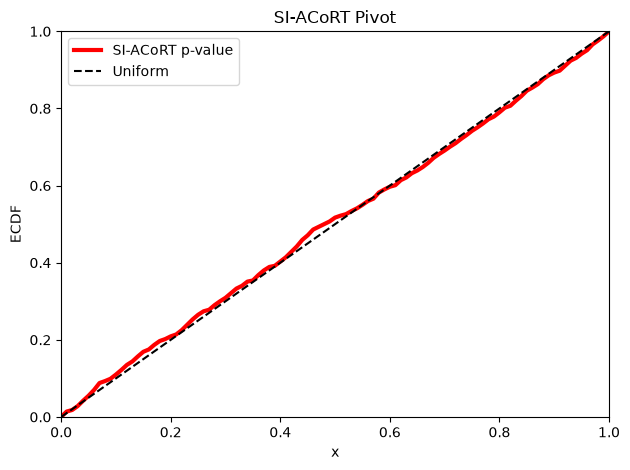

In [3]:
p_values, _ = run_pivot_experiment()

print(kstest(p_values, 'uniform'))

grid = np.linspace(0.0, 1.0, 101)
ecdf = np.searchsorted(np.sort(p_values), grid, side='right') / len(p_values)
plt.plot(grid, ecdf, color='red', linewidth=3, label='SI-ACoRT p-value')
plt.plot([0.0, 1.0], [0.0, 1.0], color='black', linestyle='--', label='Uniform')
plt.xlabel('x')
plt.ylabel('ECDF')
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)
plt.title('SI-ACoRT Pivot')
plt.legend()
plt.tight_layout()
plt.show()